<a href="https://colab.research.google.com/github/husseinlopez/IAdesdeCero2026/blob/main/3.2%20-%20penguins_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# **Curso IA desde Cero**

* Dr. Irvin Hussein López Nava
* M.C. Joan M. Raygoza Romero

## Librerias

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import mutual_info_classif

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc, make_scorer
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## Cargar datos

Eliminar datos faltantes, mostrar los primeros 5 datos y obtener estadísticos.

In [2]:
df = pd.read_csv("penguins.csv")
df = df.dropna()

print(df.head())
print(df.describe())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    male  
1       3800.0  female  
2       3250.0  female  
4       3450.0  female  
5       3650.0    male  
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  355

### Seleccionar la columna objetivo (columna a predecir)

In [3]:
target_col = "species"

X = df.drop(columns=[target_col])
y = df[target_col]

### Preprocesamiento

Convertir datos discretos a ordinales.



In [4]:
categorical_cols = X.select_dtypes(include=["object"]).columns

encoder = OrdinalEncoder()

X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)

['Adelie' 'Chinstrap' 'Gentoo']


### Rankear variables

In [6]:
scores = mutual_info_classif(X, y, random_state=42)

rank_df = pd.DataFrame({
    "Variable": X.columns,
    "Score": scores
}).sort_values("Score", ascending=False)

rank_df

,Variable,Score
3,flipper_length_mm,0.621977
2,bill_depth_mm,0.570236
1,bill_length_mm,0.538438
0,island,0.529837
4,body_mass_g,0.501956
5,sex,0.043368


### Scatterplot de los datos

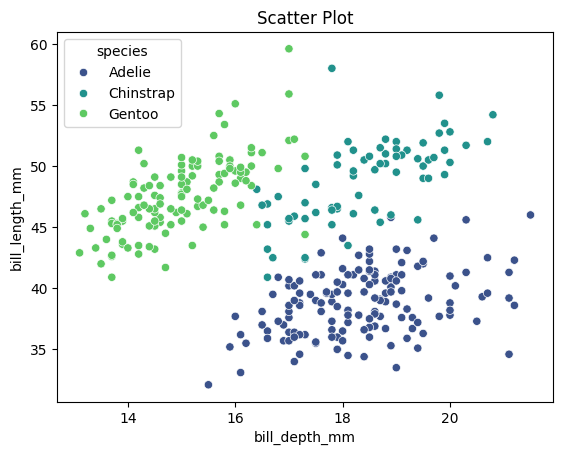

In [7]:
sns.scatterplot(
    data=df,
    x='bill_depth_mm',
    y='bill_length_mm',
    hue=target_col,
    palette='viridis'
)

plt.title("Scatter Plot")
plt.show()

### Scatterplot y distribución de los datos

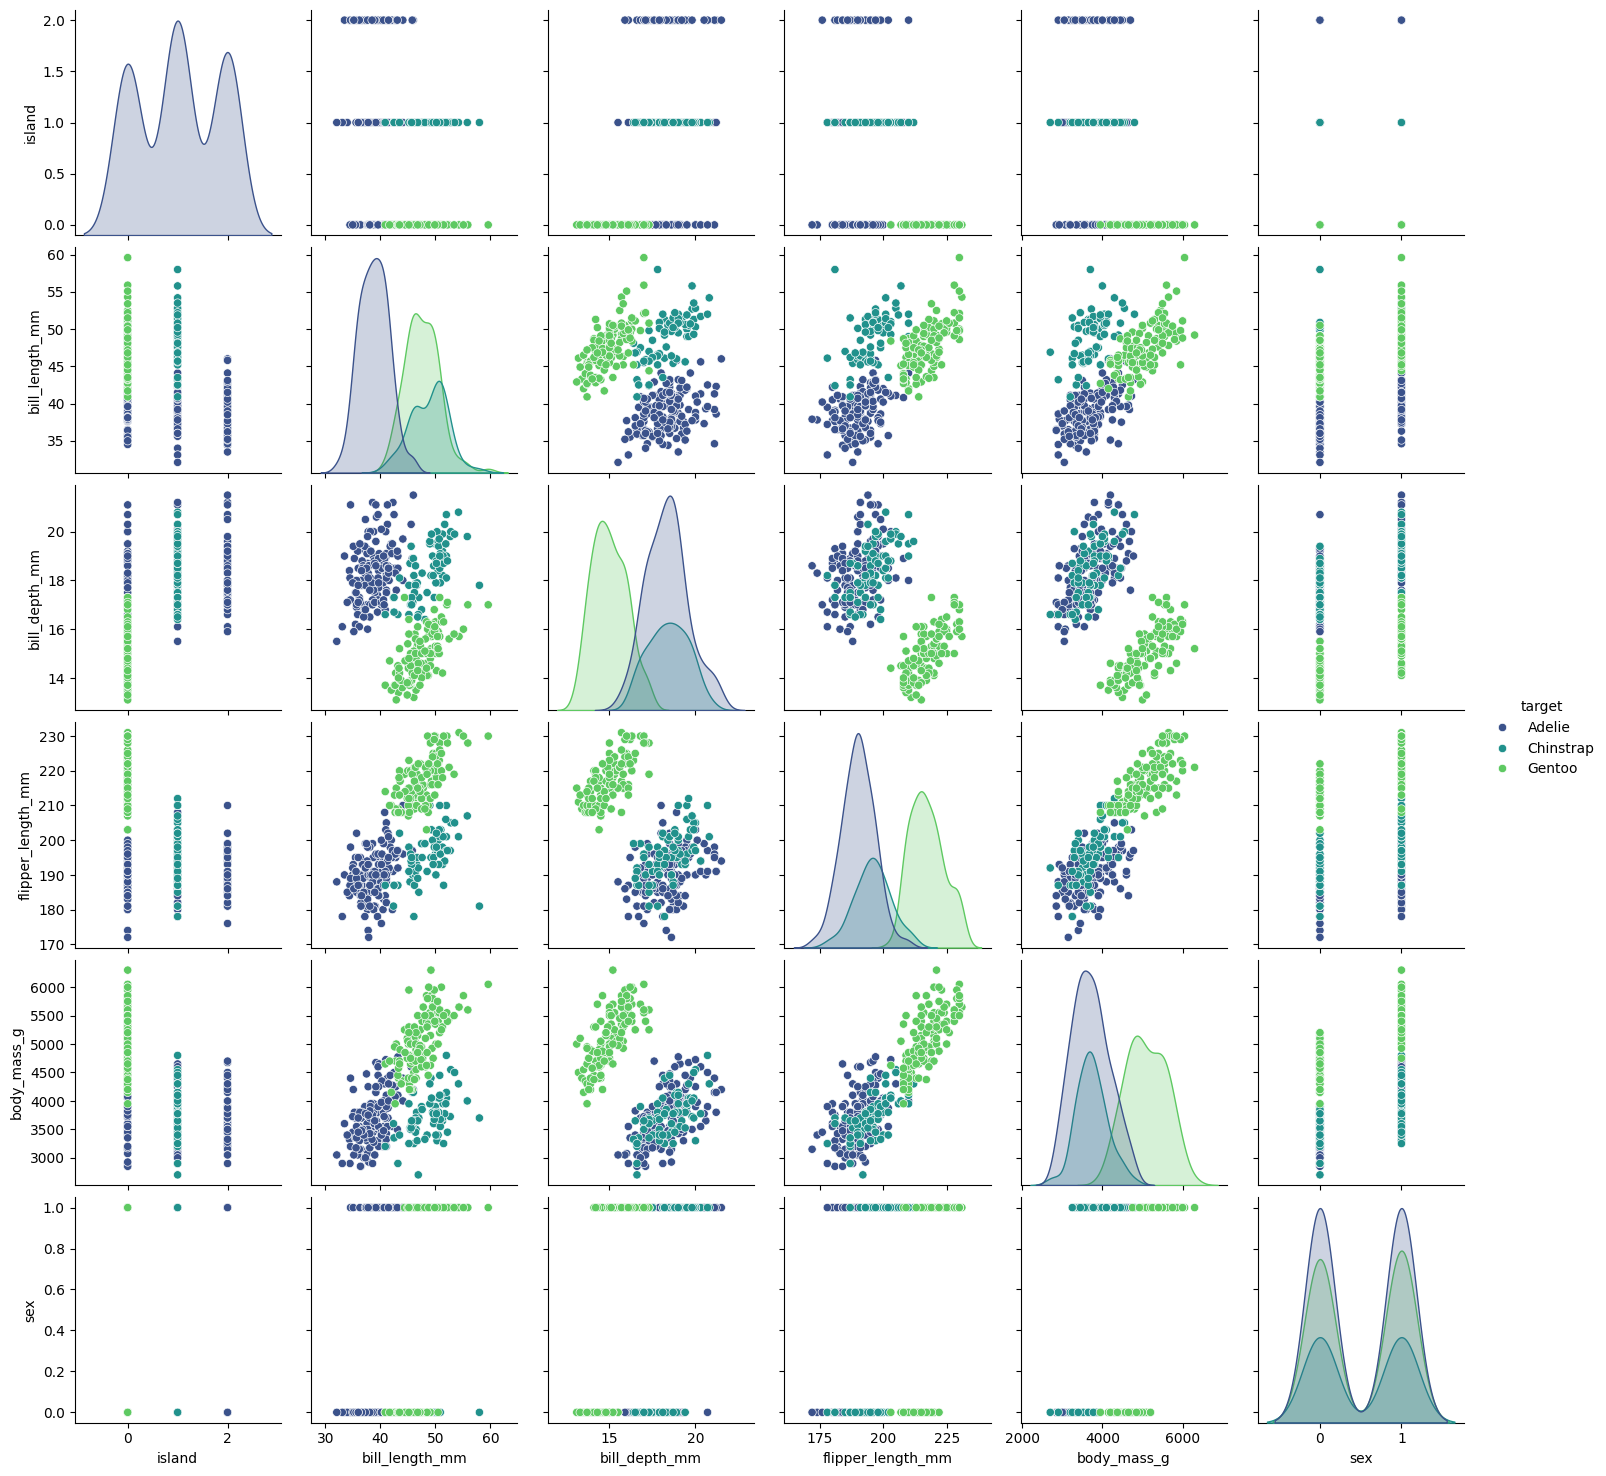

In [8]:
X_plot = X.copy()
X_plot["target"] = df[target_col]

sns.pairplot(
    data=X_plot,
    hue="target",
    palette='viridis'
)

### Modelos a usar

In [9]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42,
        class_weight="balanced"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=1000,
        random_state=42
    )
}

## Entrenamiento

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
}

results = []
trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "Modelo": name,

        "Accuracy mean": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),

        "F1 macro mean": scores["test_f1_macro"].mean(),
        "F1 macro std": scores["test_f1_macro"].std(),

        "Precision macro mean": scores["test_precision_macro"].mean(),
        "Precision macro std": scores["test_precision_macro"].std(),

        "Recall macro mean": scores["test_recall_macro"].mean(),
        "Recall macro std": scores["test_recall_macro"].std(),
    })

    pipe.fit(X, y)
    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values(
    "F1 macro mean",
    ascending=False
)

results_df

,Modelo,Accuracy mean,Accuracy std,F1 macro mean,F1 macro std,Precision macro mean,Precision macro std,Recall macro mean,Recall macro std
2,SVM,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
0,kNN,0.993939,0.007423,0.992893,0.008709,0.990794,0.011287,0.995402,0.005631
1,Random Forest,0.991000,0.007349,0.989133,0.008885,0.988643,0.010310,0.990274,0.009473
3,Logistic Regression,0.991000,0.011963,0.988655,0.015311,0.991071,0.010976,0.987445,0.019869
7,Neural Network,0.991000,0.011963,0.988655,0.015311,0.991071,0.010976,0.987445,0.019869
5,AdaBoost,0.981954,0.006129,0.978277,0.007725,0.979311,0.009650,0.978085,0.009657
6,Tree,0.960968,0.007318,0.957719,0.010316,0.960413,0.012146,0.958206,0.014703
4,Naive Bayes,0.834600,0.049266,0.825837,0.051121,0.852508,0.029863,0.874483,0.036828


### Seleccionar el mejor modelo y obtener métricas

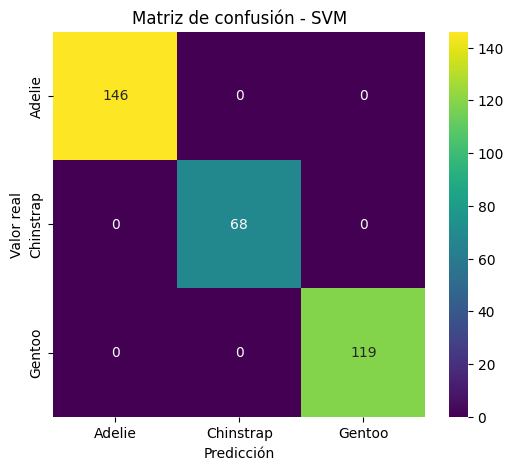

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00       146
   Chinstrap       1.00      1.00      1.00        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           1.00       333
   macro avg       1.00      1.00      1.00       333
weighted avg       1.00      1.00      1.00       333



In [11]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_model)
])

y_pred = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv
)

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión - {best_model_name}")

plt.show()

print(
    classification_report(
        y,
        y_pred,
        target_names=le.classes_
    )
)